# **Proyek Klasifikasi Gambar Sampah**
- **Nama:** Azhar Zuhro
- **Email:** azharzuhro49@student.cs.unida.gontor.ac.id
- **ID Dicoding:** azhar zuhro

## **Import Libraries**

In [1]:
import os
import shutil
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import zipfile
from google.colab import drive

from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout,Flatten

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

## **Konfigurasi Dataset & Parameter**

In [2]:
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/dataset waste/dataset waste.zip'
extract_path = '/content/dataset_waste'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print(f"File berhasil diekstrak ke: {extract_path}")


Mounted at /content/drive
File berhasil diekstrak ke: /content/dataset_waste


In [3]:
BASE_PATH = "/content/dataset_waste"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

## **Visualisasi Contoh Gambar & Resolusi**

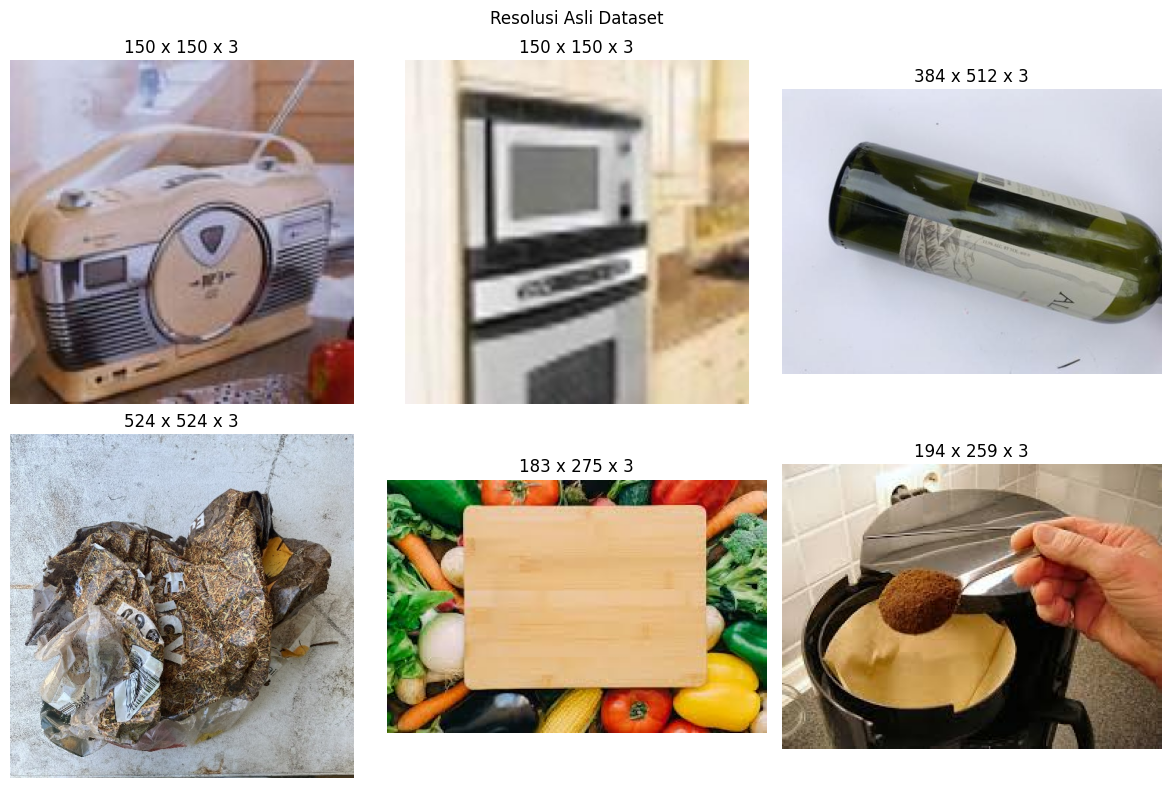

In [4]:
sample_paths = []

for cls in os.listdir(BASE_PATH):
    cls_path = os.path.join(BASE_PATH, cls)
    if os.path.isdir(cls_path):
        imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
        for img in random.sample(imgs, min(2, len(imgs))):
            sample_paths.append(os.path.join(cls_path, img))

plt.figure(figsize=(12, 8))
for i, p in enumerate(sample_paths[:6]):
    img = cv2.imread(p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"{h} x {w} x {c}")
    plt.axis("off")

plt.suptitle("Resolusi Asli Dataset")
plt.tight_layout()
plt.show()


## **Cek Resolusi Gambar**

In [5]:
image_shapes = set()

for cls in os.listdir(BASE_PATH):
    cls_path = os.path.join(BASE_PATH, cls)
    if not os.path.isdir(cls_path):
        continue

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            image_shapes.add(img.shape)

print("Jumlah resolusi unik:", len(image_shapes))
print("Contoh resolusi:", list(image_shapes)[:10])


Jumlah resolusi unik: 499
Contoh resolusi: [(161, 314, 3), (263, 192, 3), (1024, 768, 3), (245, 206, 3), (250, 201, 3), (195, 259, 3), (227, 223, 3), (182, 277, 3), (189, 267, 3), (228, 222, 3)]


## **Persiapan Dataset (Path & Label)**

In [6]:
def get_dataset_path(base_path):
    classes = sorted(os.listdir(base_path))
    file_paths, labels = [], []

    for i, class_name in enumerate(classes):
        class_dir = os.path.join(base_path, class_name)
        for file_name in os.listdir(class_dir):
            if file_name.lower().endswith(('.jpg','.jpeg','.png')):
                file_paths.append(os.path.join(class_dir, file_name))
                labels.append(i)

    return file_paths, labels, classes

file_paths, labels, class_names = get_dataset_path(BASE_PATH)
print(f"Total gambar: {len(file_paths)}")
print(f"Jumlah kelas: {len(class_names)}")


Total gambar: 12761
Jumlah kelas: 3


## **Split Dataset (Train / Validation / Test)**

In [7]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    file_paths, labels, test_size=0.3, stratify=labels, random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)


## **Dataset Pipeline (Preprocessing & Augmentasi)**

In [8]:
def preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.2)
    return img, label

def create_dataset(paths, labels, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_paths, train_labels, augment=True)
val_ds   = create_dataset(val_paths, val_labels)
test_ds  = create_dataset(test_paths, test_labels)

print(f"Train      : {len(train_paths)}")
print(f"Validation : {len(val_paths)}")
print(f"Test       : {len(test_paths)}")

Train      : 8932
Validation : 1914
Test       : 1915


## **Modelling**

In [9]:
def build_model(num_classes):
    pre_trained_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=IMG_SIZE + (3,)
    )

    for layer in pre_trained_model.layers:
        layer.trainable = False

    model = Sequential()
    model.add(pre_trained_model)

    model.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten(name="flatten"))
    model.add(Dropout(0.5))
    model.add(Dense(128, activation="relu"))
    model.add(Dense(num_classes, activation="softmax"))

    return model


In [10]:
model = build_model(len(class_names))
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 32)       │       368,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,653,859 (10.12 MB)

 Trainable params: 395,875 (1.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
# Callback
early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    patience=2,
    factor=0.2
)


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights))

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 71s 170ms/step - accuracy: 0.3659 - loss: 1.4390 - val_accuracy: 0.8083 - val_loss: 0.7512 - learning_rate: 1.0000e-05
Epoch 2/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.6341 - loss: 0.8104 - val_accuracy: 0.9112 - val_loss: 0.3632 - learning_rate: 1.0000e-05
Epoch 3/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - accuracy: 0.8268 - loss: 0.4694 - val_accuracy: 0.9399 - val_loss: 0.2147 - learning_rate: 1.0000e-05
Epoch 4/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.8951 - loss: 0.3080 - val_accuracy: 0.9530 - val_loss: 0.1597 - learning_rate: 1.0000e-05
Epoch 5/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.9181 - loss: 0.2459 - val_accuracy: 0.9577 - val_loss: 0.1422 - learning_rate: 1.0000e-05
Epoch 6/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - accuracy: 0.9361 - loss: 0.2009 - val_accuracy: 0.9598 - val_loss: 0.1305 - learning_rate: 1.0000e-05
Epoch 7/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/st

## **Evaluasi Model**

In [13]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 228ms/step - accuracy: 0.9609 - loss: 0.1177
Test Accuracy: 96.50%


### **Plot Akurasi & Loss**

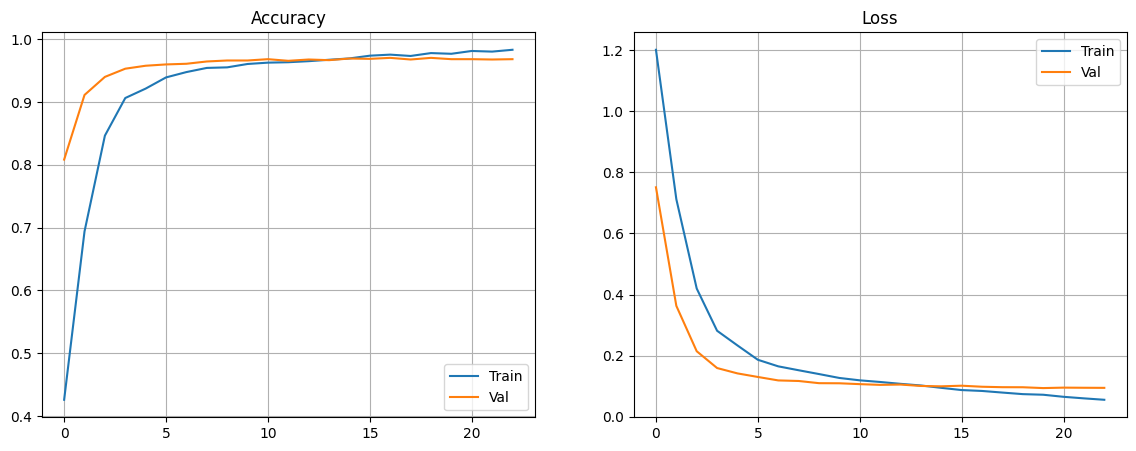

In [14]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.grid()

plt.show()


### **Save Model**

In [15]:
# SavedModel
model.export("savedmodel")

Saved artifact at 'savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136504600042512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136504600042896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136504600045392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136504600044816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136504600044048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136504600042704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136504600045584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136504600046352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136504600045968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136504600045008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136504600045200:

In [16]:
# convert tflite
converter = tf.lite.TFLiteConverter.from_saved_model("savedmodel")
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

In [21]:
# convert tfjs
!pip install -U tensorflowjs
!tensorflowjs_converter \
  --input_format=tf_saved_model \
  --output_format=tfjs_graph_model \
  savedmodel model.tfjs

2026-01-23 00:56:58.178205: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769129818.256148    6479 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769129818.286435    6479 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769129818.367846    6479 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769129818.369138    6479 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769129818.369163    6479 computation_placer.cc:177] computation placer alr

### **Confusion Matrix**

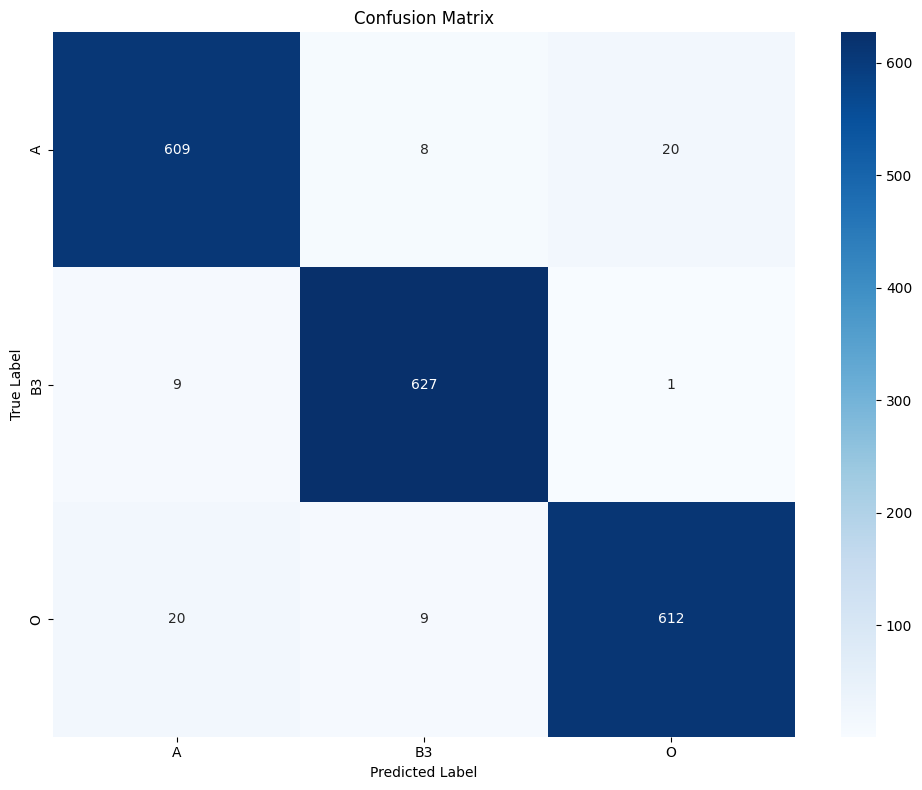

In [23]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## **Inference**

Saving biological74.jpg to biological74 (2).jpg
Predicted    : Organik
Confidence   : 99.10%


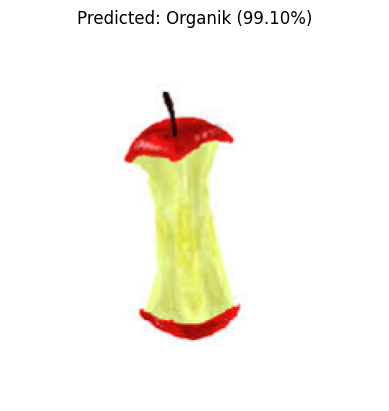

In [36]:
from PIL import Image
from google.colab import files

class_names = ["Anorganik", "B3", "Organik"]

# Load TF-Lite model
interpreter = tf.lite.Interpreter(model_path="/content/model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Upload gambar
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load gambar
img = Image.open(img_path).convert("RGB")

input_height = input_details[0]['shape'][1]
input_width  = input_details[0]['shape'][2]

img = img.resize((input_width, input_height))
img_array = np.array(img) / 255.0
input_data = np.expand_dims(img_array, axis=0).astype(np.float32)

# Inference TF-Lite
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
pred = interpreter.get_tensor(output_details[0]['index'])[0]

pred_class = np.argmax(pred)
confidence = np.max(pred) * 100

# Tampilkan hasil
print("Predicted    :", class_names[pred_class])
print("Confidence   :", f"{confidence:.2f}%")

# Visualisasi gambar
plt.imshow(img)
plt.title(f"Predicted: {class_names[pred_class]} ({confidence:.2f}%)")
plt.axis("off")
plt.show()
